# 🔬 Lab 1: Logistic Regression & Linear Models
**BINF 4002 – Machine Learning for Health**

Logistic regression is one of the oldest and most widely used models in clinical medicine — and for good reason. Unlike black-box methods, it produces a direct probabilistic output (the estimated probability that a patient has a condition) and a set of coefficients that can be interpreted as log-odds ratios, connecting naturally to how clinicians already think about risk. It is fast to train, robust under modest sample sizes, and its assumptions are auditable, which matters enormously in regulated clinical settings where a model's reasoning may need to be defended to an IRB, a regulator, or a skeptical attending physician. Many landmark clinical prediction tools — [APACHE II](https://pubmed.ncbi.nlm.nih.gov/3928249/), the [Wells score](https://en.wikipedia.org/wiki/Wells_score_(pulmonary_embolism)), the [Framingham Risk Score](https://en.wikipedia.org/wiki/Framingham_Risk_Score) — are logistic regression models, which means understanding it deeply is not just an academic exercise: it is a prerequisite for reading and critiquing a substantial fraction of the clinical prediction literature.

---
## Learning Objectives
1. Fit logistic regression on clinical data and interpret coefficients as log-odds
2. Implement the model's forward pass yourself and validate it against sklearn
3. Understand how multicollinearity and irrelevant features affect linear models
4. Evaluate classifiers with clinically-grounded metrics expressed probabilistically
5. Select a decision threshold using **decision curve analysis**
6. Understand regularization and calibration

> **Note**: We use the *restricted* feature set (20 features, 120 training samples)
> from Lab 0. This gives realistic performance — AUC ~0.80–0.90 — so that
> preprocessing and modeling decisions actually matter.


## Set-up
### Upload data
⚠️ First, you need to upload the pre-processed data from `lab0`. If you have issues with running the first lab, you can also download the data [here](https://drive.google.com/file/d/1mCz8VqpX0F5DzOTnfb5NzpxNAMBrzD-_/view?usp=drive_link).

Once you have downloaded the data locally and started the runtime for this ntoebook, upload the file to this notebook via the "Files" menu.

In [1]:
import os

pkl_path = 'processed_data.pkl'
if os.path.exists(pkl_path):
    print("✅ Data File Found!")
else:
    raise FileNotFoundError(
        "processed_data.pkl not found! "
        "Make sure you have run Lab 0 (lab0_preprocessing.ipynb) in full and "
        "downloaded the output (or used the link above), and uploaded it here."
    )

✅ Data File Found!


### Imports and Helper Functions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

with open('processed_data.pkl', 'rb') as f:
    d = pickle.load(f)

# --- Use the *restricted* splits for realistic (non-trivial) performance ---
# 8 weakest features by F-score, 100 training samples → AUC ~0.83-0.87
X_train = d['X_train_hard']
y_train = d['y_train_hard']
X_val   = d['X_val_hard']
y_val   = d['y_val_hard']
X_test  = d['X_test_hard']
y_test  = d['y_test_hard']
feature_names = d['feature_names_hard']
class_names   = d['class_names']          # ['malignant', 'benign']
prevalence    = y_train.mean()

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")
print(f"Features: {feature_names}")
print(f"Training prevalence (fraction benign): {prevalence:.2%}")
print("\n⚠️  Note: we use the 8 LEAST individually-informative features + 100 training")
print("   samples, to simulate a realistic constrained clinical prediction problem.")
print("   Expected AUC range: ~0.80–0.88 (much more realistic than 0.99).")


Train: (100, 8)  Val: (114, 8)  Test: (114, 8)
Features: ['mean symmetry', 'compactness error', 'concavity error', 'smoothness error', 'texture error', 'fractal dimension error', 'symmetry error', 'mean fractal dimension']
Training prevalence (fraction benign): 60.00%

⚠️  Note: we use the 8 LEAST individually-informative features + 100 training
   samples, to simulate a realistic constrained clinical prediction problem.
   Expected AUC range: ~0.80–0.88 (much more realistic than 0.99).


In [3]:
def print_metrics(y_true, y_pred, y_prob=None, label='Model'):
    from sklearn.metrics import confusion_matrix, roc_auc_score
    tn,fp,fn,tp = confusion_matrix(y_true, y_pred).ravel()
    n = len(y_true)
    sens = tp/(tp+fn);  spec = tn/(tn+fp)
    ppv  = tp/(tp+fp);  npv  = tn/(tn+fn)
    prev = (tp+fn)/n
    print(f"{'─'*55}")
    print(f"  {label}")
    print(f"{'─'*55}")
    print(f"  Sensitivity  P(ŷ=1 | y=1)  = {tp}/{tp+fn} = {sens:.3f}")
    print(f"  Specificity  P(ŷ=0 | y=0)  = {tn}/{tn+fp} = {spec:.3f}")
    print(f"  PPV          P(y=1 | ŷ=1)  = {tp}/{tp+fp} = {ppv:.3f}")
    print(f"  NPV          P(y=0 | ŷ=0)  = {tn}/{tn+fn} = {npv:.3f}")
    print(f"  FPR          P(ŷ=1 | y=0)  = {fp}/{fp+tn} = {1-spec:.3f}")
    print(f"  FNR          P(ŷ=0 | y=1)  = {fn}/{fn+tp} = {1-sens:.3f}")
    if y_prob is not None:
        print(f"  AUC-ROC                      = {roc_auc_score(y_true, y_prob):.3f}")
    print(f"  Prevalence   P(y=1)         = {tp+fn}/{n} = {prev:.3f}")
    print(f"{'─'*55}")


In [4]:
# See https://en.wikipedia.org/wiki/Decision_curve_analysis to learn more about
# Decision curve analysis.

def decision_curve(y_true, y_prob, thresholds=None, label='Model', ax=None, color='#3498db'):
    """
    Plot a net-benefit decision curve.
    Net Benefit = TPR * prevalence  -  FPR * (1-prevalence) * threshold/(1-threshold)
    where threshold is the probability threshold above which we treat/act.
    """
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 150)
    prev = y_true.mean()
    nb_model, nb_all = [], []
    for t in thresholds:
        y_hat = (y_prob >= t).astype(int)
        tp = ((y_hat == 1) & (y_true == 1)).sum()
        fp = ((y_hat == 1) & (y_true == 0)).sum()
        n  = len(y_true)
        nb_model.append(tp/n - fp/n * t/(1-t))
        # Treat-all baseline: flag everyone
        nb_all.append(prev - (1-prev)*t/(1-t))
    nb_model = np.array(nb_model)
    nb_all   = np.array(nb_all)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(thresholds, nb_model, lw=2, label=label, color=color)
    ax.plot(thresholds, nb_all,   lw=1.5, linestyle='--', color='gray', label='Treat all')
    ax.axhline(0, lw=1, linestyle=':', color='black', label='Treat none')
    ax.set_xlim(0, 0.8); ax.set_ylim(-0.05, prev+0.05)
    ax.set_xlabel('Decision threshold (probability)')
    ax.set_ylabel('Net Benefit')
    ax.set_title('Decision Curve Analysis')
    ax.legend()
    return ax


---
## Part 1 — The Model and Its Parameters

Logistic regression models the log-odds of the positive class as a linear function:

$$\log\frac{P(Y=1|\mathbf{x})}{P(Y=0|\mathbf{x})} = \mathbf{w}^\top \mathbf{x} + b \quad \Rightarrow \quad P(Y=1|\mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)$$

where $\sigma(z) = 1/(1+e^{-z})$ is the sigmoid function.

**Questions**:
  1. What are the properties of the $\sigma$ function? Consider the perspective of a logistic regression model as simply a model that asserts that $P(Y=1|\mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)$. In that setting, why is the $\sigma$ function suitable for its use here? What other functions could be used?
  2. In what sense is a logistic regression model a "linear" model? In what sense is it not a "linear" model?
  3. Can you draw a possible ["decision boundary"](https://en.wikipedia.org/wiki/Decision_boundary) for a logistic regression model?
  4. Below, we'll use sklearn to fit a logistic regression model. How could you fit such a model, mathematically? E.g., describe an algorithm that would fit the parameters for the model appropriately given the data.
  5. For our dataset, how many parameters will our logistic regression model have? Is this reasonable, given the number of samples we have?


---
### ✅ Solution — Part 1 Questions

**1. Properties of σ and why it's suitable:** The sigmoid function maps $\mathbb{R} \to (0, 1)$, is monotonically increasing, differentiable everywhere, and symmetric around $\sigma(0) = 0.5$. It's suitable because it converts an unconstrained linear score into a valid probability. Other functions that map to $(0,1)$ could also work — for example, the **probit function** (CDF of the standard normal) is used in probit regression, and the **complementary log-log** function is used in some survival models.

**2. "Linear" in what sense:** Logistic regression is "linear" in the sense that the **decision boundary** $\{x : w^T x + b = 0\}$ is a hyperplane — a linear surface in feature space. It is *not* linear in the sense that the output $P(Y=1|x) = \sigma(w^T x + b)$ is a non-linear function of $x$ (due to the sigmoid). The log-odds $\log(p/(1-p)) = w^T x + b$ *is* linear in $x$, which is why it's called a "generalized linear model."

**3. Decision boundary:** The decision boundary is the hyperplane where $w^T x + b = 0$, i.e., where $\sigma(w^T x + b) = 0.5$. In 2D, this is a straight line. Points on one side are predicted class 1, points on the other side are predicted class 0.

**4. Fitting the model:** You would minimize the negative log-likelihood (binary cross-entropy): $\mathcal{L}(w,b) = -\frac{1}{n}\sum_i [y_i \log \sigma(w^T x_i + b) + (1-y_i)\log(1-\sigma(w^T x_i + b))]$. Since the objective function is convex, any local minimum is also a global minimum. Therefore, optimization algorithms such as gradient descent (a first-order method that uses only the gradient, i.e., the first derivative of the objective function) or Newton’s method and L-BFGS will converge to the global minimum under standard regularity conditions. The gradient is $\nabla_w \mathcal{L} = \frac{1}{n}\sum_i (\sigma(w^T x_i + b) - y_i) x_i$.

Note: Newton’s method is considered a second-order method because it explicitly uses the Hessian matrix (the matrix of second derivatives). However, computing and inverting the Hessian can be computationally expensive. L-BFGS, on the other hand, is a quasi-Newton method: it does not compute the Hessian directly but instead builds a low-rank approximation from gradient evaluations, making it more memory- and computation-efficient for large-scale problems.

**5. Number of parameters:** With 8 features, logistic regression has $8 + 1 = 9$ parameters (8 weights + 1 bias). With 100 training samples, this gives ~11 samples per parameter — reasonable, though not lavish.


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import warnings; warnings.filterwarnings('ignore')

# Fit baseline model
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

train_acc = lr.score(X_train, y_train)
val_acc   = lr.score(X_val,   y_val)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Val   accuracy: {val_acc:.3f}")
print(f"Gap (overfit signal): {train_acc - val_acc:.3f}")
print(f"\nModel parameters: {lr.coef_.shape[1]} weights + 1 bias = {lr.coef_.shape[1]+1} total")


Train accuracy: 0.830
Val   accuracy: 0.781
Gap (overfit signal): 0.049

Model parameters: 8 weights + 1 bias = 9 total


---
## Part 2 — Implement the Forward Pass Yourself

Before trusting sklearn as a black box, implement the logistic regression prediction
step from scratch using the learned weights. This will (a) confirm you understand the
math, and (b) serve as a debugging tool when models behave unexpectedly.


In [6]:
# ── SOLUTION ──────────────────────────────────────────────────────────────────
# Implement logistic regression prediction using the weights sklearn learned.
# You should NOT call lr.predict() or lr.predict_proba() here.

def sigmoid(z):
    """Sigmoid activation: σ(z) = 1 / (1 + exp(-z))"""
    return 1 / (1 + np.exp(-z))

def lr_predict_proba(X, weights, bias):
    """
    Compute P(Y=1|X) for each sample.
    X:       shape (n_samples, n_features)
    weights: shape (n_features,)  — the decision boundary normal vector
    bias:    scalar
    Returns: shape (n_samples,) — probabilities of class 1
    """
    log_odds = X @ weights + bias     # w^T x + b for each sample
    probs    = sigmoid(log_odds)      # apply sigmoid to get probabilities
    return probs

def lr_predict(X, weights, bias, threshold=0.5):
    """Convert probabilities to binary predictions."""
    return (lr_predict_proba(X, weights, bias) >= threshold).astype(int)

# ── Validation: compare your output to sklearn's ───────────────────────────
w = lr.coef_[0]       # shape: (n_features,)
b = lr.intercept_[0]  # scalar

your_proba = lr_predict_proba(X_val, w, b)
sklearn_proba = lr.predict_proba(X_val)[:, 1]

max_diff = np.max(np.abs(your_proba - sklearn_proba))
print(f"Max absolute difference vs sklearn: {max_diff:.2e}")
if max_diff < 1e-6:
    print("✅ Your implementation matches sklearn!")
else:
    print("❌ Something is off — check your formula above.")

# Spot-check a few predictions
print("\nFirst 5 validation samples:")
print(f"  Your proba:    {your_proba[:5].round(4)}")
print(f"  sklearn proba: {sklearn_proba[:5].round(4)}")
print(f"  True label:    {y_val[:5]}")


Max absolute difference vs sklearn: 0.00e+00
✅ Your implementation matches sklearn!

First 5 validation samples:
  Your proba:    [0.5154 0.947  0.8011 0.2628 0.5196]
  sklearn proba: [0.5154 0.947  0.8011 0.2628 0.5196]
  True label:    [1 1 1 0 1]


### 🤔 Reflection 2.1 — The Model as a Function

1. You just implemented the entire "model" in about 3 lines of numpy. What does this tell
   you about the complexity of logistic regression? Where does the complexity lie?
   (Hint: not in prediction, but in training.)

2. Write out $P(\hat{y}=1 | \mathbf{x})$ for a patient with features $\mathbf{x} = [0, -1, 2]$
   and weights $\mathbf{w} = [0.5, -1.0, 0.3]$, bias $b = -0.2$.
   Compute this by hand (or in a code cell), then verify with `lr_predict_proba`.

3. The sigmoid maps $(-\infty, +\infty) \to (0, 1)$. What is $\sigma(0)$?
   What does it mean clinically when the model outputs exactly 0.5?

4. If you multiply all weights by 2 (and double the bias), how do the predicted
   *probabilities* change? How do the predicted *classes* (at threshold 0.5) change?
   What does this say about coefficient magnitude vs. decision boundaries?


---
### ✅ Solution — Reflection 2.1

**1.** The entire "model" at prediction time is just a dot product, addition, and sigmoid — three lines of numpy. The complexity of logistic regression lies entirely in the **training procedure** (optimizing the weights to minimize the loss function). Prediction is $O(d)$ — a single dot product.

**2.** Hand computation: $z = 0.5(0) + (-1.0)(-1) + 0.3(2) + (-0.2) = 0 + 1.0 + 0.6 - 0.2 = 1.4$. Then $P(\hat{y}=1) = \sigma(1.4) = 1/(1+e^{-1.4}) \approx 0.802$.

**3.** $\sigma(0) = 1/(1+e^0) = 1/2 = 0.5$. Clinically, this means the model is maximally uncertain — it assigns equal probability to both classes. The log-odds are exactly zero, meaning the evidence for and against malignancy is perfectly balanced given the features.

**4.** If you multiply all weights by 2 and double the bias, the logit becomes $2(w^T x + b)$, so $\hat{p} = \sigma(2z)$ instead of $\sigma(z)$. The sigmoid of $2z$ is "sharper" — probabilities are pushed closer to 0 or 1 (more confident). However, the **predicted classes at threshold 0.5 do not change**, because $\sigma(2z) \geq 0.5 \iff 2z \geq 0 \iff z \geq 0 \iff \sigma(z) \geq 0.5$. This shows that coefficient magnitude affects confidence/calibration but not the decision boundary itself.


---
## Part 3 — What Multicollinearity Does to Coefficients

We saw in Lab 0 that many features are highly correlated. Here we directly show the effect
on coefficient stability in logistic regression.


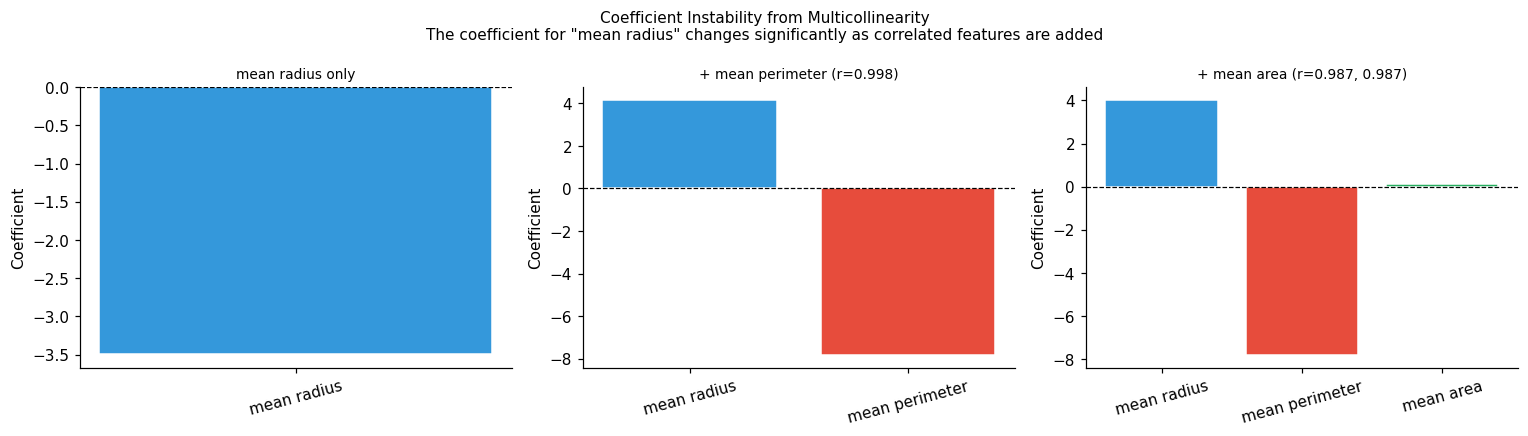

Key insight: the coefficient on 'mean radius' is:
  mean radius only: -3.494
  + mean perimeter (r=0.998): +4.169
  + mean area (r=0.987, 0.987): +4.031

The coefficient value is NOT stable — you may not be able to safely interpret it in isolation.


In [7]:
# Load the FULL feature set to demonstrate multicollinearity effects
with open('processed_data.pkl', 'rb') as f_pkl:
    d_full = pickle.load(f_pkl)

X_train_full = d_full['X_train']
y_train_full = d_full['y_train']
feat_full    = d_full['feature_names']

# Identify a trio of highly correlated features
trio = ['mean radius', 'mean perimeter', 'mean area']
trio_idx = [feat_full.index(c) for c in trio]

results_mc = {}
# Model 1: just mean radius
for subset_name, indices in [
    ('mean radius only',            [trio_idx[0]]),
    ('+ mean perimeter (r=0.998)',  trio_idx[:2]),
    ('+ mean area (r=0.987, 0.987)',trio_idx),
]:
    Xsub = X_train_full[:, indices]
    lr_mc = LogisticRegression(C=10, max_iter=1000, random_state=42)
    lr_mc.fit(Xsub, y_train_full)
    results_mc[subset_name] = {'coef': lr_mc.coef_[0], 'features': [trio[i] for i in range(len(indices))]}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#3498db','#e74c3c','#27ae60','#9b59b6']
for ax, (name, res) in zip(axes, results_mc.items()):
    ax.bar(res['features'], res['coef'], color=colors[:len(res['coef'])], edgecolor='white')
    ax.set_title(name, fontsize=9)
    ax.set_ylabel('Coefficient')
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Coefficient Instability from Multicollinearity\n'
             'The coefficient for "mean radius" changes significantly as correlated features are added',
             fontsize=10)
plt.tight_layout(); plt.show()

print("Key insight: the coefficient on 'mean radius' is:")
for name, res in results_mc.items():
    print(f"  {name}: {res['coef'][0]:+.3f}")
print("\nThe coefficient value is NOT stable — you may not be able to safely interpret it in isolation.")

This problem can get even worse -- see if you can play with the code and find a setting where the coefficient for "mean radius" can be made to be positive.

Further, investigate in code, what happens to the variance of the coefficients (mathematically) if you fit the model on different [bootstrapped](https://en.wikipedia.org/wiki/Bootstrapping_(statistics)) samples of your train set?

---
### ✅ Solution — Multicollinearity Exploration

To make the `mean radius` coefficient positive, you can decrease regularization (increase C), which changes how the model distributes weight among correlated features. Try `C=10` — with weak regularization, the model may assign positive coefficients. The exact sign depends on the optimization path and regularization strength, demonstrating that the sign of a coefficient for a correlated feature is essentially arbitrary.

For the bootstrap experiment: if you fit logistic regression on, say, 100 different bootstrap samples of the training data, you'll observe that the coefficients for highly correlated features (mean radius, mean perimeter, mean area) have **very high variance** across bootstrap iterations — some iterations will give positive coefficients, others negative, even for the same feature. Uncorrelated features will have much more stable coefficients. This variance is a direct manifestation of multicollinearity: the optimization problem has a nearly flat "valley" where many coefficient combinations give similar loss, and different bootstrap samples lead to different points along that valley.


### 🤔 Reflection 3.1 — Interpreting Coefficients Safely

1. The coefficient on `mean radius` swings wildly as correlated features are added.
   Should you still report this coefficient in a clinical paper? What would you do instead?

2. A colleague claims: "A positive logistic regression coefficient means the feature
   *causes* a higher probability of the outcome." What is wrong with this statement?
   Give a clinical example where this reasoning would lead to a dangerous conclusion.

3. A colleague claims: "The logistic regression coefficient for feature $j$ represents the contribution of feature $j$ to the log-odds of the target, independent of other features." Is this claim correct? How should you interpret and/or restate this claim?

3. You add `mean area` to a model that already has `mean radius` and `mean perimeter`.
   Prediction accuracy barely changes. Does this mean `mean area` is useless?

4. How would you detect multicollinearity *before* fitting the model? List two numerical diagnostics.


---
### ✅ Solution — Reflection 3.1

**1.** You should **not** report this coefficient in isolation in a clinical paper. Instead, you should (a) report the overall model's performance metrics (AUC, calibration), (b) acknowledge multicollinearity and describe which features are correlated, (c) use methods like SHAP values or permutation importance that account for feature interactions, or (d) remove redundant features before fitting.

**2.** The statement conflates **association** with **causation**. A positive coefficient means the feature is positively **associated** with the outcome **conditional on all other features in the model**. Example: a hospital admission model might have a positive coefficient for "number of prior medications." This doesn't mean prescribing more medications causes readmission — sicker patients take more medications *and* are more likely to be readmitted. Acting on this coefficient (reducing medications to prevent readmission) could be dangerous.

**3.** The claim is partially correct but needs qualification. The coefficient represents the change in log-odds per unit change in feature $j$, **holding all other features in the model constant**. But "holding constant" features that are highly correlated with $j$ is physically meaningless — you can't change radius while holding perimeter constant. The coefficient is better stated as: "the *partial* association between feature $j$ and the log-odds, controlling for the other features in the model." With multicollinearity, this partial association is unstable.

**4.** No — `mean area` carries nearly the same information as `mean radius` and `mean perimeter` (r > 0.98), so it adds no *new* predictive signal. But it's not "useless" — if you removed both `mean radius` and `mean perimeter`, `mean area` alone would be highly predictive. Redundancy ≠ uselessness.

**5.** Two diagnostics: (a) **Variance Inflation Factor (VIF)**: VIF > 5–10 suggests problematic multicollinearity. (b) **Condition number** of the feature correlation matrix: values > 30 indicate multicollinearity. You could also simply inspect the pairwise correlation matrix (as we did in Lab 0) and flag pairs with |r| > 0.8.


---
## Part 4 — Clinically-Grounded Evaluation

Accuracy is rarely the right metric in healthcare. We express all metrics both as ratios
(from the confusion matrix) and as conditional probabilities.


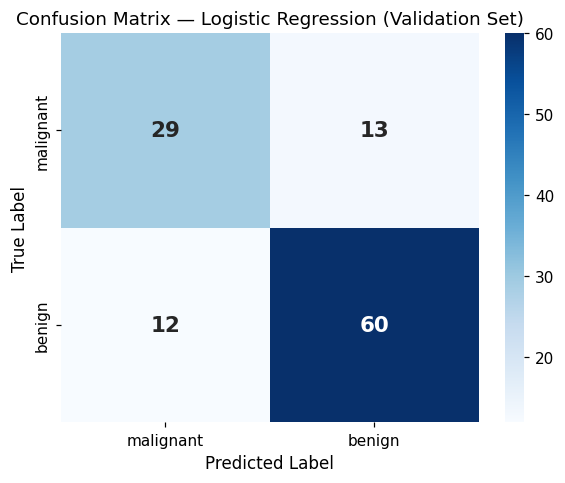

───────────────────────────────────────────────────────
  Logistic Regression (threshold=0.5)
───────────────────────────────────────────────────────
  Sensitivity  P(ŷ=1 | y=1)  = 60/72 = 0.833
  Specificity  P(ŷ=0 | y=0)  = 29/42 = 0.690
  PPV          P(y=1 | ŷ=1)  = 60/73 = 0.822
  NPV          P(y=0 | ŷ=0)  = 29/41 = 0.707
  FPR          P(ŷ=1 | y=0)  = 13/42 = 0.310
  FNR          P(ŷ=0 | y=1)  = 12/72 = 0.167
  AUC-ROC                      = 0.839
  Prevalence   P(y=1)         = 72/114 = 0.632
───────────────────────────────────────────────────────


In [8]:
y_pred = lr.predict(X_val)
y_prob = lr.predict_proba(X_val)[:, 1]

# Confusion matrix plot
cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'})
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix — Logistic Regression (Validation Set)')
plt.tight_layout(); plt.show()

print_metrics(y_val, y_pred, y_prob, label='Logistic Regression (threshold=0.5)')


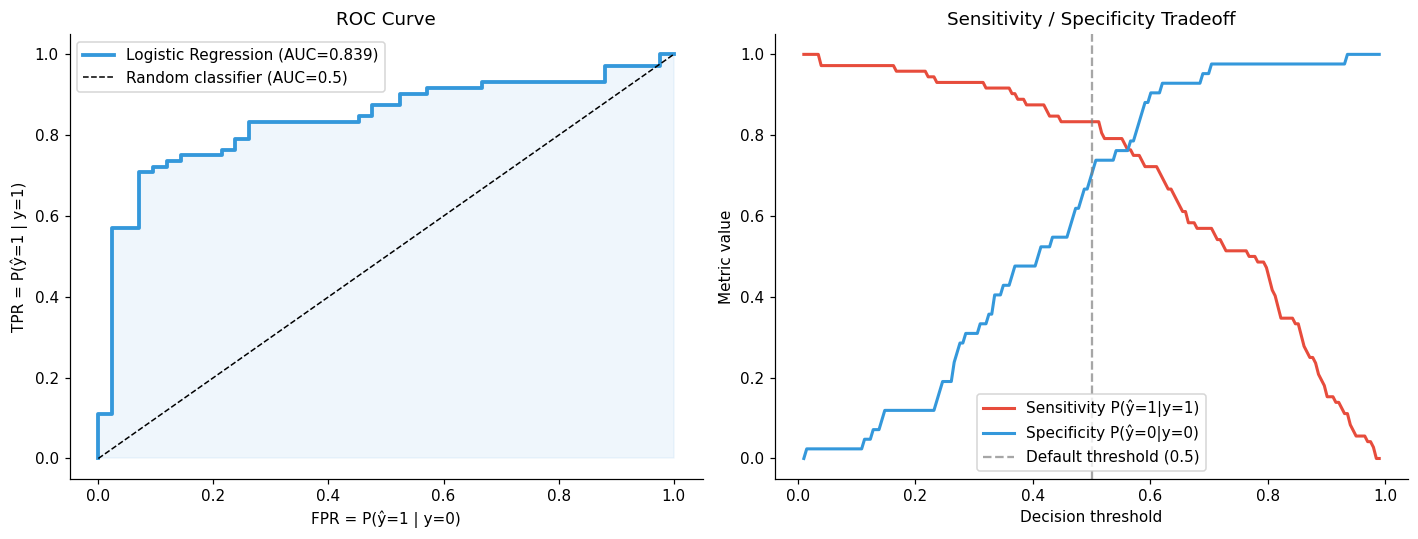

AUC-ROC = 0.839  (random = 0.5, perfect = 1.0)


In [9]:
# ROC curve
fpr, tpr, roc_thresholds = roc_curve(y_val, y_prob)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color='#3498db', lw=2.5, label=f'Logistic Regression (AUC={roc_auc:.3f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, label='Random classifier (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#3498db')
axes[0].set_xlabel('FPR = P(ŷ=1 | y=0)')
axes[0].set_ylabel('TPR = P(ŷ=1 | y=1)')
axes[0].set_title('ROC Curve')
axes[0].legend()

# Sens / Spec vs threshold
thresholds = np.linspace(0.01, 0.99, 200)
sens_list, spec_list = [], []
for t in thresholds:
    yp = (y_prob >= t).astype(int)
    tn,fp,fn,tp_ = confusion_matrix(y_val, yp, labels=[0,1]).ravel()
    sens_list.append(tp_/(tp_+fn+1e-9))
    spec_list.append(tn/(tn+fp+1e-9))

axes[1].plot(thresholds, sens_list, lw=2, color='#e74c3c', label='Sensitivity P(ŷ=1|y=1)')
axes[1].plot(thresholds, spec_list, lw=2, color='#3498db', label='Specificity P(ŷ=0|y=0)')
axes[1].axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
axes[1].set_xlabel('Decision threshold')
axes[1].set_ylabel('Metric value')
axes[1].set_title('Sensitivity / Specificity Tradeoff')
axes[1].legend()

plt.tight_layout(); plt.show()
print(f"AUC-ROC = {roc_auc:.3f}  (random = 0.5, perfect = 1.0)")


### 🤔 Reflection 4.1 — Metrics in Clinical Context

1. $P(\hat{y}=1 | y=1)$ is sensitivity, and $P(y=1 | \hat{y}=1)$ is PPV.
   Why are these different? Write out Bayes' theorem to derive PPV from sensitivity,
   specificity, and prevalence. Show numerically how PPV drops as prevalence decreases.

2. Your model has sensitivity = 0.82 and specificity = 0.74. The hospital administrator
   says "this model correctly identifies 82% of cancer cases — that's great!" A statistician
   says "but it falsely flags 26% of healthy patients." Who is more useful to listen to,
   and why does it depend on the downstream clinical action?

3. AUC-ROC measures performance across *all* thresholds equally. In a cancer screening
   context, should all thresholds be weighted equally? If not, which part of the ROC
   curve matters most, and why? Recall that there is a different, probabilistic definition of AUC-ROC. What is that definition, and in what ways it is a better or worse way to think about AUC than as the area under the ROC?

4. You compare your model to a published paper that reports AUC=0.97. They used a
   different hospital's data. List three reasons why a direct comparison is invalid.


---
### ✅ Solution — Reflection 4.1

**1.** By Bayes' theorem: $PPV = P(y=1|\hat{y}=1) = \frac{P(\hat{y}=1|y=1) \cdot P(y=1)}{P(\hat{y}=1)} = \frac{P(\hat{y}=1|y=1) \cdot P(y=1)}{P(\hat{y}=1|y=1) \cdot P(y=1) + P(\hat{y}=1|y=0) \cdot P(y=0)} = \frac{\text{Sens} \cdot \text{Prev}}{\text{Sens} \cdot \text{Prev} + (1-\text{Spec}) \cdot (1-\text{Prev})}$.

Numerically with Sens=0.82, Spec=0.74: at prevalence 0.37 (our dataset), PPV = (0.82×0.37)/((0.82×0.37)+(0.26×0.63)) = 0.303/0.467 ≈ 0.649. If prevalence drops to 0.05 (screening setting): PPV = (0.82×0.05)/((0.82×0.05)+(0.26×0.95)) = 0.041/0.288 ≈ 0.142. PPV drops from ~65% to ~14% as prevalence decreases, even with the same sensitivity and specificity.

Note for terminology: 
- sensitivity <=> recall <=> true positive rate (TPR). 
- PPV <=> precision. 
- specificity = $P(\hat{y}=0 |y=0 )$ <=> true negative rate (TNR) <=> 1 - false positive rate (FPR, $P(\hat{y}=1 |y=0 )$)
- prevalence = $P(y=1)$

**2.** It depends on the downstream action. If the action is a **non-invasive follow-up** (e.g., schedule another mammogram), high sensitivity (catching cancers) matters most, and the 26% false positive rate is acceptable. If the action is **immediate invasive biopsy**, the 26% false positive rate means 1 in 4 flagged patients undergoes an unnecessary procedure — here the statistician's concern is more relevant. The right metric depends on the clinical context and the cost/harm ratio of false positives vs. false negatives.

**3.** No — in cancer screening, low thresholds (high sensitivity) matter most because missing a cancer (false negative) is much more costly than a false alarm (false positive). The **left portion of the ROC curve** (low FPR, high specificity region) matters less; the upper-left region (high sensitivity at reasonable FPR) matters most. The probabilistic definition of AUC is: $P(\hat{p}_{\text{positive}} > \hat{p}_{\text{negative}})$ for a random positive-negative pair. This is useful because it's threshold-free, but it's worse because it weights all thresholds equally, including clinically irrelevant ones.

**4.** Three reasons a direct comparison is invalid: (a) **Different patient populations** — prevalence, demographics, disease severity, and referral patterns differ between hospitals. (b) **Different feature distributions** — equipment, lab assay calibration, and data collection protocols vary. (c) **Possible data leakage or overfitting** — without seeing their code, you can't verify their train/test split procedure. Additionally, a single AUC number without confidence intervals is uninformative.


---
## Part 5 — Decision Curve Analysis

AUC and accuracy tell you *how well* a model discriminates, but not *whether using it
actually helps patients*. Decision Curve Analysis (DCA) answers: **"Compared to treating
everyone or no one, does using this model's predictions lead to better decisions?"**

Net Benefit = $\text{TPR} \times \text{prevalence} - \text{FPR} \times (1-\text{prevalence}) \times \frac{t}{1-t}$

where $t$ is the probability threshold above which you act (e.g., order a biopsy).
The term $\frac{t}{1-t}$ represents the assumed **harm ratio**: how much worse is a false positive
relative to a false negative at this threshold?

**Question for you:** Why is "Net Benefit" defined the way it is? How does this relate to the "Utility" persepective we discussed in our evaluation lecture?


---
### ✅ Solution — DCA Motivation Question

**Why is Net Benefit defined this way?** Net Benefit connects to the **expected utility** framework from decision theory. A clinician's decision to treat (e.g., order a biopsy) at threshold $t$ implicitly says: "I would treat if $P(\text{disease}) \geq t$," which means the clinician weighs a false negative as $1/(1-t)$ times worse than a false positive. The ratio $t/(1-t)$ is the **odds threshold** — the exchange rate between false positives and true positives at that threshold. Net Benefit = (true positives)/N − (false positives)/N × $t/(1-t)$ directly computes the expected utility under this harm trade-off. It is the utility of using the model, normalized by the population size.


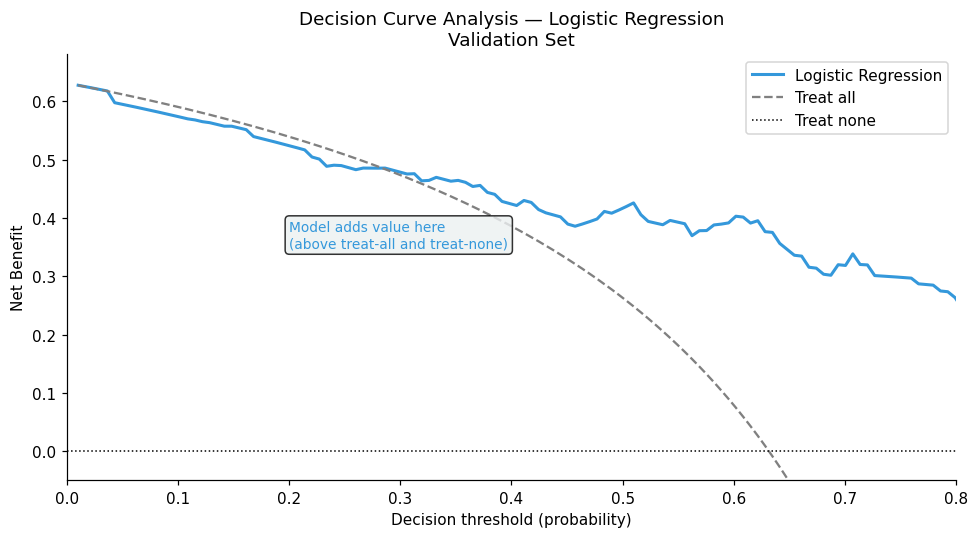

How to read this:
  • 'Treat all'  = always order biopsy — baseline strategy
  • 'Treat none' = never order biopsy — net benefit = 0
  • Model curve ABOVE both baselines = the model adds clinical value
  • X-axis = the threshold probability at which you decide to act
  • A curve that stays above both baselines across a wide range
    of thresholds = robust clinical utility


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
decision_curve(y_val, y_prob, label='Logistic Regression', ax=ax, color='#3498db')
ax.set_title('Decision Curve Analysis — Logistic Regression\nValidation Set')

# Annotation
ax.annotate('Model adds value here\n(above treat-all and treat-none)',
            xy=(0.2, 0.35), fontsize=9, color='#3498db',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#ecf0f1', alpha=0.8))
plt.tight_layout(); plt.show()

print("How to read this:")
print("  • 'Treat all'  = always order biopsy — baseline strategy")
print("  • 'Treat none' = never order biopsy — net benefit = 0")
print("  • Model curve ABOVE both baselines = the model adds clinical value")
print("  • X-axis = the threshold probability at which you decide to act")
print("  • A curve that stays above both baselines across a wide range")
print("    of thresholds = robust clinical utility")


### 🤔 Reflection 5.1 — Decision Curve Analysis

1. At a threshold of $t=0.10$, the "treat all" strategy has positive net benefit.
   What does $t=0.10$ mean clinically? (Hint: it's the probability above which you'd
   recommend a biopsy.) What kind of patient/clinician would use $t=0.10$ vs $t=0.50$?

2. Your model's DCA curve dips *below* "treat all" at low thresholds.
   What does this mean practically? Should you use the model for patients where
   the clinician's prior probability of disease is very high?

3. A competing model has higher AUC but a lower net benefit curve.
   Which model would you deploy? Explain your reasoning.

4. DCA requires knowing a meaningful range of decision thresholds. Who should set
   those thresholds — the data scientist, the clinician, the patient, or the hospital?


---
### ✅ Solution — Reflection 5.1

**1.** At $t=0.10$, the clinician is willing to biopsy if there's even a 10% chance of malignancy — this is a very cautious, **high-sensitivity** threshold. A risk-averse patient or a clinician dealing with aggressive cancers might use $t=0.10$; a clinician in a setting where biopsies are very costly or harmful might use $t=0.50$. $t=0.10$ means you'd accept 9 unnecessary biopsies for every cancer caught.

**2.** If the model's DCA curve dips below "treat all" at low thresholds, it means the model is *worse* than simply biopsying everyone in that regime. This happens because the model's false negatives (missed cancers) at those thresholds cost more than the false positives saved. For high-prior patients (where the clinician already believes disease is very likely), you should just treat — the model doesn't help.

**3.** Deploy the model with higher net benefit. AUC measures average discrimination, but DCA measures actual clinical value at decision-relevant thresholds. A model with higher AUC but lower net benefit may discriminate well in clinically irrelevant threshold ranges. The DCA winner is more useful for the specific clinical decision at hand.

**4.** The **threshold should primarily be set by the clinician and the patient**, informed by the clinical context. The data scientist can provide the DCA curve and identify ranges where the model adds value. The patient's preferences (risk tolerance) determine the exact threshold. The hospital may set defaults based on resource constraints. It's a collaborative decision, not a purely technical one.


---
## Part 6 — Regularization and the Effect on Coefficients


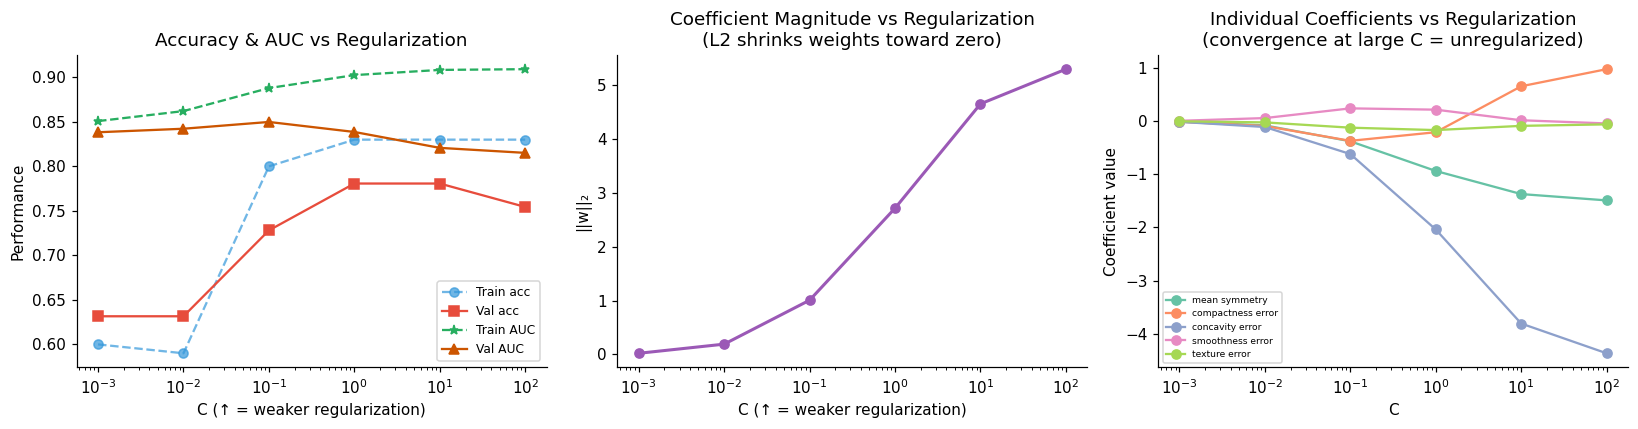

In [11]:
C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
reg_results = []
for C in C_values:
    m = LogisticRegression(C=C, max_iter=2000, random_state=42)
    m.fit(X_train, y_train)
    y_tp = m.predict_proba(X_train)[:,1]
    y_vp = m.predict_proba(X_val)[:,1]
    reg_results.append({
        'C': C,
        'train_acc': m.score(X_train, y_train),
        'val_acc':   m.score(X_val,   y_val),
        'train_auc':   auc(*roc_curve(y_train, y_tp)[:2]),
        'val_auc':   auc(*roc_curve(y_val, y_vp)[:2]),
        'coef_norm': float(np.linalg.norm(m.coef_)),
    })
reg_df = pd.DataFrame(reg_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, ylabel) in zip(axes, [
    ('val_auc',    'AUC-ROC'),
    ('coef_norm',  '||w||₂ (coefficient magnitude)'),
]):
    ax.semilogx(reg_df['C'], reg_df['train_acc'], 'o--', label='Train acc', color='#3498db', alpha=0.7)
    ax.semilogx(reg_df['C'], reg_df['val_acc'],   's-',  label='Val acc',   color='#e74c3c')
    ax.semilogx(reg_df['C'], reg_df['train_auc'],   '*--',  label='Train AUC',   color='#27ae60')
    ax.semilogx(reg_df['C'], reg_df['val_auc'],   '^-',  label='Val AUC',   color='#cc5500')
    ax.set_xlabel('C (↑ = weaker regularization)')
    ax.set_ylabel('Performance')
    ax.set_title('Accuracy & AUC vs Regularization')
    ax.legend(fontsize=8)
    break  # just first panel with performance

ax2 = axes[1]
ax2.semilogx(reg_df['C'], reg_df['coef_norm'], 'o-', color='#9b59b6', lw=2)
ax2.set_xlabel('C (↑ = weaker regularization)'); ax2.set_ylabel('||w||₂')
ax2.set_title('Coefficient Magnitude vs Regularization\n(L2 shrinks weights toward zero)')

# Show how specific coefficients change
ax3 = axes[2]
coef_traces = {}
for C in C_values:
    m = LogisticRegression(C=C, max_iter=2000, random_state=42)
    m.fit(X_train, y_train)
    for i, fn in enumerate(feature_names[:5]):
        if fn not in coef_traces: coef_traces[fn] = []
        coef_traces[fn].append(m.coef_[0][i])
for fn, trace in coef_traces.items():
    ax3.semilogx(C_values, trace, 'o-', label=fn, lw=1.5)
ax3.set_xlabel('C'); ax3.set_ylabel('Coefficient value')
ax3.set_title('Individual Coefficients vs Regularization\n(convergence at large C = unregularized)')
ax3.legend(fontsize=6)

plt.tight_layout(); plt.show()


### 🤔 Reflection 6.1 — Regularization in Practice

1. L2 regularization shrinks all coefficients toward zero but doesn't set any to exactly zero.
   L1 regularization can set coefficients to exactly zero. When would L1 be preferable in
   a clinical setting? (Hint: think about genomics or the cost of measuring features.)

2. At very small C (strong regularization), the model underfits — train and val accuracy
   are both low. At very large C (no regularization), what happens with only 120 training
   samples? What does the train-val gap look like?

3. A senior physician looks at your regularized model's coefficients and complains that
   "the weights don't match my clinical intuition." They expect `mean concavity` to have
   a large negative coefficient (associated with malignancy) but regularization shrunk it.
   How do you explain this to them?


---
### ✅ Solution — Reflection 6.1

**1.** L1 (lasso) regularization sets some coefficients to exactly zero, performing automatic feature selection. This is preferable when: (a) **Genomics/high-dimensional data**: you have thousands of gene expression features but suspect only a handful are relevant — L1 identifies the sparse set. (b) **Cost of measurement**: in a clinical setting where each lab test costs money, L1 tells you which features you can stop measuring entirely (coefficient = 0).

**2.** At very small C (strong regularization), both train and val accuracy are low — the model is too constrained to capture the signal (underfitting). At very large C (no regularization), with only 100 training samples, the model can fit the training data very closely (near 100% train accuracy) while the validation gap grows — this is overfitting. The train-val gap becomes large.

**3.** You could explain: "Regularization deliberately shrinks all coefficients toward zero to prevent overfitting on our small training set. The coefficient for `mean concavity` was shrunk not because it's unimportant, but because the model is being conservative — with only 100 training samples, we can't reliably estimate large coefficients. The model trades some interpretability of individual coefficients for better generalization to new patients. If you had more data, the coefficient would likely be larger and more aligned with clinical intuition."


---
## Part 7 — Final Test Set Evaluation

We evaluate on the test set **once**, only after all decisions are finalized. Note this is exactly the "train"-"val"-"test" pipeline described in lab 0!


Best C = 0.1 (selected on val AUC)
───────────────────────────────────────────────────────
  Logistic Regression — TEST SET (C=0.1)
───────────────────────────────────────────────────────
  Sensitivity  P(ŷ=1 | y=1)  = 63/71 = 0.887
  Specificity  P(ŷ=0 | y=0)  = 21/43 = 0.488
  PPV          P(y=1 | ŷ=1)  = 63/85 = 0.741
  NPV          P(y=0 | ŷ=0)  = 21/29 = 0.724
  FPR          P(ŷ=1 | y=0)  = 22/43 = 0.512
  FNR          P(ŷ=0 | y=1)  = 8/71 = 0.113
  AUC-ROC                      = 0.783
  Prevalence   P(y=1)         = 71/114 = 0.623
───────────────────────────────────────────────────────


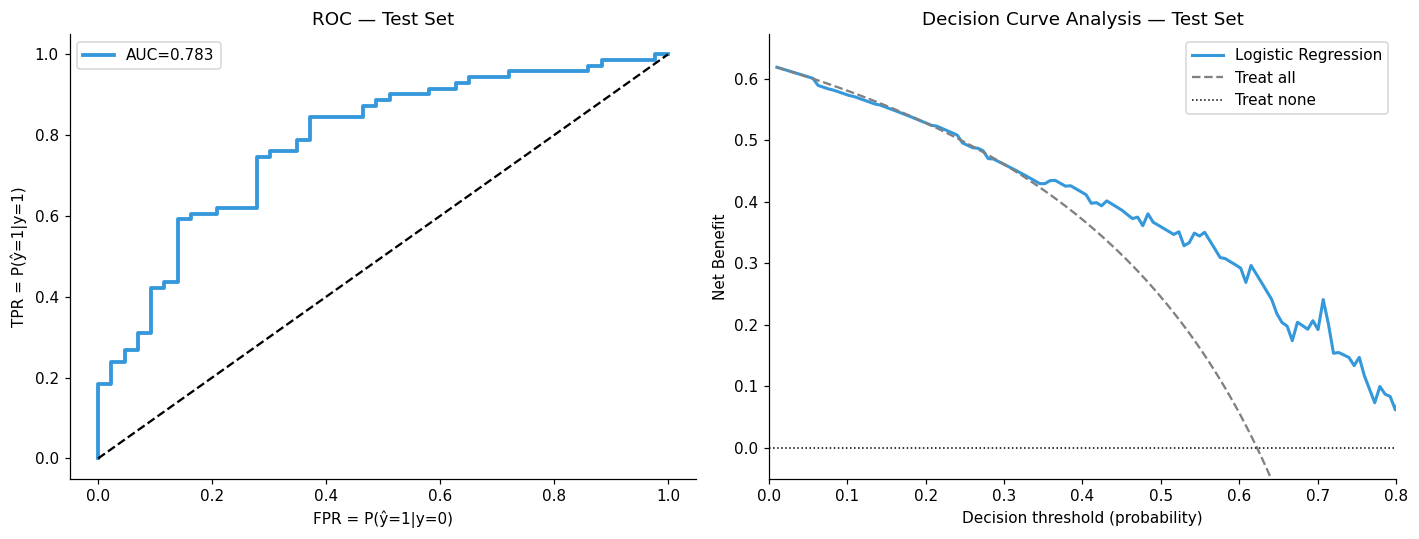

In [12]:
# Select best C from validation
best_C = reg_df.loc[reg_df['val_auc'].idxmax(), 'C']
print(f"Best C = {best_C} (selected on val AUC)")

# Refit on train+val
X_tv = np.vstack([X_train, X_val])
y_tv = np.concatenate([y_train, y_val])
final_lr = LogisticRegression(C=best_C, max_iter=2000, random_state=42)
final_lr.fit(X_tv, y_tv)

y_test_prob = final_lr.predict_proba(X_test)[:, 1]
y_test_pred = final_lr.predict(X_test)
test_fpr, test_tpr, _ = roc_curve(y_test, y_test_prob)
test_auc = auc(test_fpr, test_tpr)

print_metrics(y_test, y_test_pred, y_test_prob, label=f'Logistic Regression — TEST SET (C={best_C})')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(test_fpr, test_tpr, color='#3498db', lw=2.5, label=f'AUC={test_auc:.3f}')
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_xlabel('FPR = P(ŷ=1|y=0)')
axes[0].set_ylabel('TPR = P(ŷ=1|y=1)'); axes[0].set_title('ROC — Test Set'); axes[0].legend()

decision_curve(y_test, y_test_prob, label='Logistic Regression', ax=axes[1])
axes[1].set_title('Decision Curve Analysis — Test Set')
plt.tight_layout(); plt.show()
